# Ask with a list of images

Minimal demo: send a list of images plus a text prompt to `ask_chatgpt()`.

Edit `IMAGE_PATHS` and `PROMPT` below, then run all cells.

In [5]:
print("Importing libraries...")
import sys, os
import time

sys.path.insert(0, os.path.abspath('..'))

from camera_reasoning.chatgpt_client import ask_chatgpt

Importing libraries...


## Configure images and prompt

In [12]:
REFERENCE_IMAGES = [
    ("skull_001", "../reference_views_medical/skull/skull_001.png", "This is the RIGHT lateral view of the skull."),
    ("skull_002", "../reference_views_medical/skull/skull_002.png", "This is the FRONT (anterior) view of the skull."),
    ("skull_003", "../reference_views_medical/skull/skull_003.png", "This is the LEFT lateral view of the skull."),
]

QUERY_IMAGES = [
    ("view_x", "../output/screenshots/rollouts/step_001/ELEVATION_DOWN_COARSE.png"),
    ("view_y", "../output/screenshots/rollouts/step_000/AZIMUTH_RIGHT_COARSE.png")
]

IMAGE_PATHS = [path for _, path in QUERY_IMAGES] + [path for _, path, _ in REFERENCE_IMAGES]

PROMPT = """
The images are provided in the following order:

Query images:
1. view_x
2. view_y

Reference images:
3. skull_001 — RIGHT lateral view of the skull
4. skull_002 — FRONT (anterior) view of the skull
5. skull_003 — LEFT lateral view of the skull

Pair each query image with the single reference image that has the most
similar skull orientation and viewpoint.

Evaluate the visible anatomical structures and the direction from which the
skull is viewed. Ignore image quality, lighting, scale, cropping, and rendering
style unless they affect orientation recognition.

Do not infer the answer from filenames, IDs, file paths, or camera-action names.
Base the pairing only on visual similarity.

The same reference image may be selected for more than one query image if it
is visually the closest match.

Return only valid JSON in this exact format:

{
  "view_x": {
    "reference_id": "skull_001 | skull_002 | skull_003",
    "reason": "Brief visual explanation"
  },
  "view_y": {
    "reference_id": "skull_001 | skull_002 | skull_003",
    "reason": "Brief visual explanation"
  }
}
"""

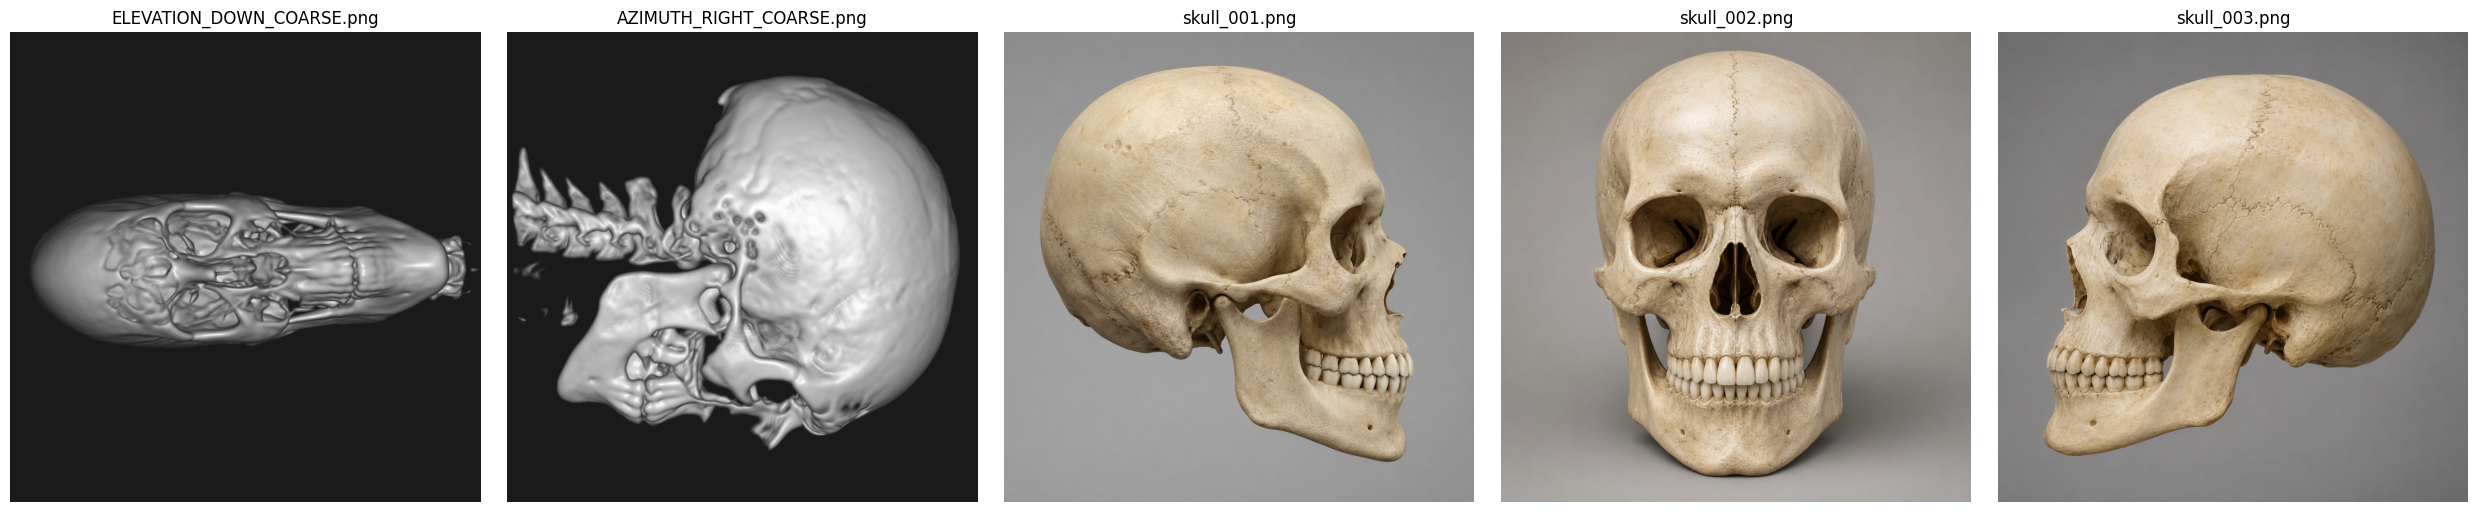

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(5 * len(IMAGE_PATHS), 5))
if len(IMAGE_PATHS) == 1:
    axes = [axes]

for ax, path in zip(axes, IMAGE_PATHS):
    ax.imshow(Image.open(path))
    ax.set_title(os.path.basename(path))
    ax.axis("off")

plt.tight_layout()
plt.show()

## Run

In [15]:
# The first query image goes in screenshot_path (unlabeled, referred to as
# "the very first image" in the prompt); the second query image and the three
# skull references are all labeled so the model can refer back to them by name.
screenshot_path = QUERY_IMAGES[0][1]
extra_images = [QUERY_IMAGES[1]]

print("LLM starts processing...")
start = time.perf_counter()
response = ask_chatgpt(
    prompt=PROMPT,
    screenshot_path=screenshot_path,
    extra_images=extra_images,
    reference_items=REFERENCE_IMAGES,
)
elapsed = time.perf_counter() - start

print(response)
print(f"\n[Elapsed: {elapsed:.2f}s]")

LLM starts processing...
```json
{
  "view_x": {
    "reference_id": "skull_002",
    "reason": "View from above showing the cranial vault, nasal cavity, orbital structures, and dental arcade from a superior perspective, matching the anterior orientation where these structures are visible from the front."
  },
  "view_y": {
    "reference_id": "skull_003",
    "reason": "Lateral view showing the left side of the skull with the cranium, zygomatic arch, mandible, and teeth visible in profile, matching the left lateral orientation."
  }
}
```

[Elapsed: 6.05s]
